The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Epoch 0 with train loss: 0.2802840915703496 and eval loss: 0.13570699902872244
Epoch 1 with train loss: 0.097299245900886 and eval loss: 0.13543445616960526
Epoch 2 with train loss: 0.0945682994328266 and eval loss: 0.19035568491866192
Epoch 3 with train loss: 0.09142823508659075 and eval loss: 0.13298289695133766
Epoch 4 with train loss: 0.08939524722653766 and eval loss: 0.1267915703356266
Epoch 5 with train loss: 0.0878597087291784 and eval loss: 0.12189958896487951
Epoch 6 with train loss: 0.08625139226747114 and eval loss: 0.13255512279768786
Epoch 7 with train loss: 0.08561842026578825 and eval loss: 0.1581452547882994
Epoch 8 with train loss: 0.08448263288064059 and eval loss: 0.12484730190287034
Epoch 9 with train loss: 0.08449678140324215 and eval loss: 0.13465975193927684
Epoch 10 with train loss: 0.08514106698160948 and eval loss: 0.13833030251165232
Epoch 11 with train loss: 0.0848778892

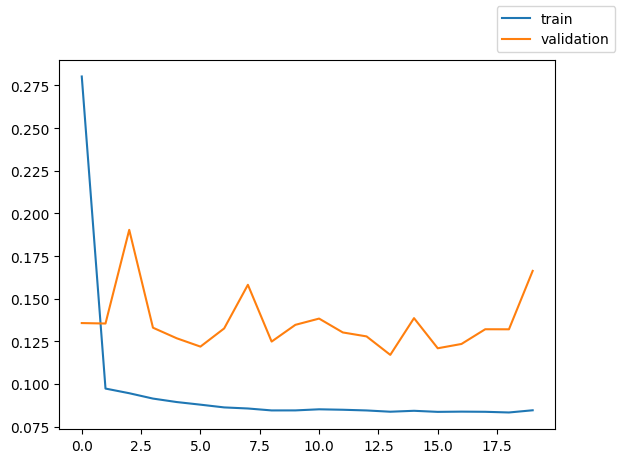

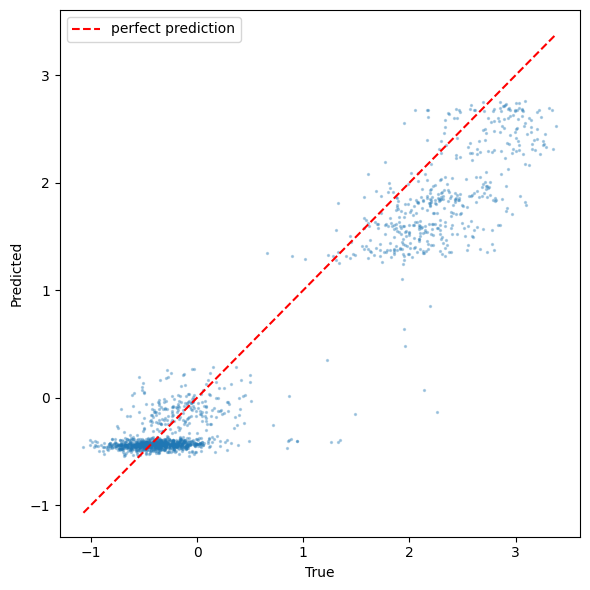

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pickle

%load_ext autoreload
%autoreload 2

from data_helpers import prepare_this_data, torchify_this_data
from model_stuff import model_setup

df = pd.read_csv('../data/CESMDataset_Try.csv')

target_col = 'SFWF'
feature_cols = ['AMOC', 'PD_200m']
lag = 50
horizon = 1
n = len(df)
train_end = int(n * 0.7)
test_end = int(n * 0.9)
batch_size = 128

X_train_lag, y_train_lag, X_test_lag, y_test_lag, X_eval_lag, y_eval_lag, y_scaler, x_scaler = prepare_this_data(df, 
                                                                                                                 target_col, 
                                                                                                                 feature_cols,
                                                                                                                 train_end,
                                                                                                                 test_end,
                                                                                                                 lag,
                                                                                                                 horizon)

X_train_t, y_train_t, train_loader, X_test_t, y_test_t, test_loader, X_eval_t, y_eval_t, eval_loader = torchify_this_data(batch_size, 
                                                                                                                          X_train_lag, 
                                                                                                                          y_train_lag, 
                                                                                                                          X_test_lag, 
                                                                                                                          y_test_lag, 
                                                                                                                          X_eval_lag, 
                                                                                                                          y_eval_lag)
device = "cpu"
n_epochs = 20

params = {
    'n_features': len(feature_cols),
    'hidden_size': 64,
    'num_layers': 1,
    'dropout': 0.0,
    'lr': 1e-3,
    'loss_fn': nn.MSELoss()
}

NN_SFWF, train_losses, eval_losses = model_setup(device, params, n_epochs, train_loader, eval_loader, X_eval_t, y_eval_lag)

torch.save({
    'state_dict': NN_SFWF.state_dict(),
    'config': {
        'n_features': len(feature_cols),
        'hidden_size': 64,
        'num_layers': 1,
        'dropout': 0.0,
    },
}, 'SFWF_model.pth')

with open('scalers_SFWF.pkl', 'wb') as f:
    pickle.dump({'y_scaler': y_scaler, 'x_scaler': x_scaler}, f)
